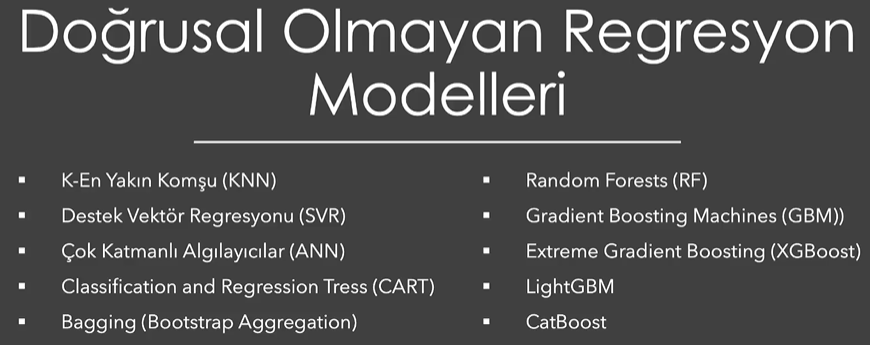

# KNN : K-Nearest Neighbor Algorithm (En yakın Komşu)

* Tahminler, gözlemlerin benzerliğine göre yapılır.
* Parametrik olmayan bir öğrenme türüdür.
* Büyük verisetlerinde performans açısından çok da iyi olduğu söylenemez.
* Classification problemleri için ortaya çıkmış, daha sonra regression problemlerine uyarlanmıştır.
* Normalde bir gözlem biriminin bağımlı değişkenini, verisetiyle eğittiğimiz makina öğrenimi modelinin tahminine göre yapardık, burada eğer bir gözlem birimi gelipte benim bağımlı değişkenim ne derse, KNN ona, senin ben 10 tane komşuna(ona en çok benzeyene) bakayım der, bakar ve prediction'ını yapar.
* 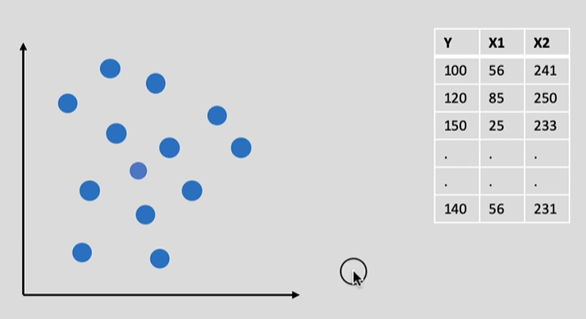
* 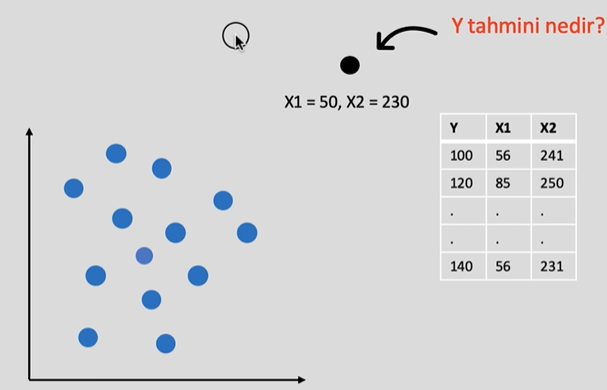
* 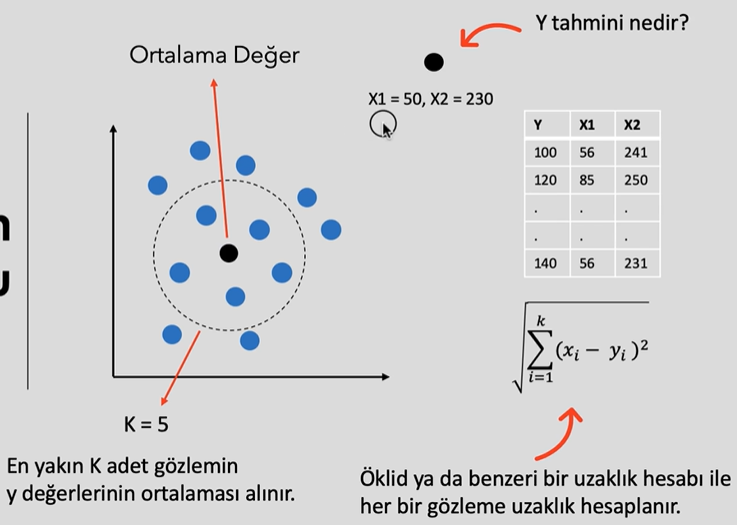

Bura resimlerde anlatılan şey, ilk resimde normal verisetimiz var. İkinci resimde yeni bir X1 gözlem birimi (tahmin edilecek değer) geliyor ve onun Y değerini bulmamız isteniyor. Biz bunu bulabilmek için bu X'in değerlerini alıp, verisetimiz içerisindeki tüm verilere olan uzaklığını hesaplıyoruz. Sonra örneğin kendisine en yakın olan 5 tane değeri bulup, onların ortalamasını alıp, ortalamalarının denk geldiği kısma bu değeri koyuyoruz.

* 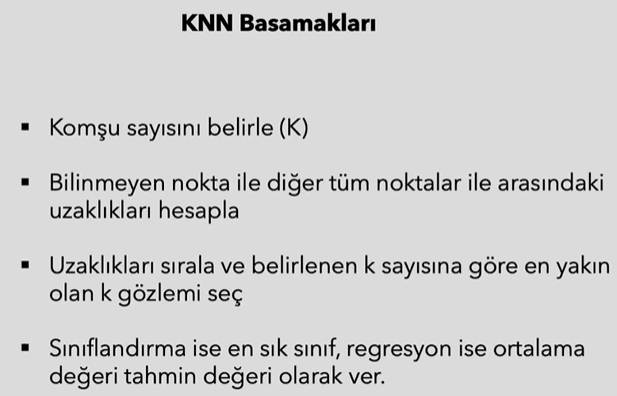

## Verisetini Düzenleme

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, ShuffleSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale
from sklearn import model_selection
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import cross_val_score

In [6]:
hit = pd.read_csv("Hitters.csv") # bazı basketbolcuların özelliklerini veren veriseti

df = hit.copy()

df = df.dropna()

dms = pd.get_dummies(df[['League', 'Division', 'NewLeague']])

y = df["Salary"] # bağımlı değişkenimizi kaydetmiş olduk

X_ = df.drop(["Salary","League","Division","NewLeague"],axis=1).astype("float")

X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Model Training (Modelin Eğitilmesi)

In [8]:
knn_model = KNeighborsRegressor().fit(X_train, y_train)

In [9]:
knn_model.n_neighbors # Knn'in hiper parametresi komşuluk parametresidir. default değeri 5'dir. verisetimiz için ne olması gerektiğine Model Tuning bölümünde incelememizi yaptıktan sonra karar vereceğiz

5

## Model Prediction - Training (Modelin Tahmin Etmesi)

In [11]:
y_pred = knn_model.predict(X_train)

## Training Error

In [13]:
np.sqrt(mean_squared_error(y_pred, y_train)) # train hatası

239.6467132541376

## Model Prediction -Test (Modelin Tahmin Etmesi)

In [15]:
y_pred = knn_model.predict(X_test)

## Test Error

In [17]:
np.sqrt(mean_squared_error(y_pred, y_test))

426.6570764525201

## Model Tuning Değil!

Aşağıdaki işlem, bir hiper parametre bulma algoritması olmasına rağmen bir model tuning değil. Çünkü Cross Validation ile yapmıyoruz ve training veriseti üzerinde çalışıyoruz. Buradan öğrenebileceğimiz şey: Model overfitting, underfitting ve eğitim hataları durumlarını inceleme fırsatı sunar. Eğer gerçek bir Model Tuning işlemi yapmak istersek, bunu CV ile yapmalı ve test verisine de bir bakmalıyız! Yani bu, eğitim üzerinde hata gözlemleme işlemidir, model tuning değil!

In [20]:
RMSE = []

for k in range(10):
    k = k + 1
    knn_model = KNeighborsRegressor(n_neighbors=k).fit(X_train, y_train)
    y_pred = knn_model.predict(X_train)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    RMSE.append(rmse)
    print("k =", k, "için RMSE değeri: ", rmse)

k = 1 için RMSE değeri:  0.0
k = 2 için RMSE değeri:  179.52761335480352
k = 3 için RMSE değeri:  205.20157172291863
k = 4 için RMSE değeri:  220.5139794876305
k = 5 için RMSE değeri:  239.6467132541376
k = 6 için RMSE değeri:  243.5904190007242
k = 7 için RMSE değeri:  258.1478781634636
k = 8 için RMSE değeri:  266.05374203349805
k = 9 için RMSE değeri:  269.73782093553376
k = 10 için RMSE değeri:  271.2798300436963


## Model Tuning

GridSearchCV Metoduyla Model Tuning yapacağız, yani bu algoritma için hiperparametremiz k olduğundan, optimum k sayısını bulucaz diyebiliriz.

In [23]:
from sklearn.model_selection import GridSearchCV

In [24]:
knn_params = {'n_neighbors':np.arange(1,30,1)} # 1'den 30'a kadar 1 1 artan sayıları, k için denemesi adına bir numpy dictionary'si oluşturduk

knn = KNeighborsRegressor()

knn_cv_model = GridSearchCV(knn, knn_params, cv=10) # 10 katlı cross validation yaparak ve k parametresi için şu değerleri kullanarak knn algoritması için model tuning işlemi yap

In [25]:
knn_cv_model.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])})

In [26]:
knn_cv_model.best_params_["n_neighbors"] # tüm sayıları denedikten sonra parametreyi buldu. bu veriseti için en iyi k parametresi 8 imiş

8

In [27]:
RMSE = []
RMSE_CV = []

for k in range(10):
    k = k + 1
    knn_model = KNeighborsRegressor(n_neighbors=k).fit(X_train, y_train)
    y_pred = knn_model.predict(X_train)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    rmse_cv = np.sqrt(-1 * cross_val_score(knn_model, X_train, y_train, cv=10, scoring="neg_mean_squared_error").mean())
    RMSE.append(rmse)
    RMSE_CV.append(rmse_cv)
    print("k =", k, "için RMSE değeri:", rmse, "RMSE_CV değeri:", rmse_cv)

# burada çıktılara bakarsak eğer şunu fark ederiz, cross valide edilmiş hatalarda standart sapma çok düşük. yani daha dengel bir şey elde etmişiz. 293'den başlıyor, 10 değer sonra vardığı nokta 301, aradaki fark 8. 
# ancak tune edilmemiş kısımda ise 179'dan başlanıp 271'de bitiriliyor. aradaki fark 91.

k = 1 için RMSE değeri: 0.0 RMSE_CV değeri: 325.3947514706382
k = 2 için RMSE değeri: 179.52761335480352 RMSE_CV değeri: 293.24000183333817
k = 3 için RMSE değeri: 205.20157172291863 RMSE_CV değeri: 283.7486667487823
k = 4 için RMSE değeri: 220.5139794876305 RMSE_CV değeri: 286.3240222024089
k = 5 için RMSE değeri: 239.6467132541376 RMSE_CV değeri: 290.0705466132226
k = 6 için RMSE değeri: 243.5904190007242 RMSE_CV değeri: 298.1263115575851
k = 7 için RMSE değeri: 258.1478781634636 RMSE_CV değeri: 294.77070479194987
k = 8 için RMSE değeri: 266.05374203349805 RMSE_CV değeri: 291.98672028891235
k = 9 için RMSE değeri: 269.73782093553376 RMSE_CV değeri: 295.7162739573105
k = 10 için RMSE değeri: 271.2798300436963 RMSE_CV değeri: 301.31047022701154


## Final Model

In [29]:
knn_tuned = KNeighborsRegressor(n_neighbors = knn_cv_model.best_params_["n_neighbors"]).fit(X_train, y_train) # bulduğumuz en optimum parametre ile modeli tekrardan kurduk

## Tune işleminden sonra hata kontrolü - Train

In [31]:
y_pred = knn_tuned.predict(X_train)

In [32]:
np.sqrt(mean_squared_error(y_pred, y_train))

266.05374203349805

## Tune işleminden sonra hata kontrolü - Test

In [34]:
y_pred = knn_tuned.predict(X_test)

In [35]:
np.sqrt(mean_squared_error(y_pred, y_test))

413.7094731463598

# Support Vector Regression - SVR (Destek Vektör Regresyonu)

**Amaç:** Bir marjin aralığında maksimum noktayı en küçük hata ile alabilecek şekilde doğru ya da eğriyi belirlemektir.

**Farkı:** Diğer regresyonlardan farklı olarak, SVR “verilerin çoğu bu doğrunun çok yakınında olsun, bazıları uzak olsa da çok önemli değil” der. Yani küçük bir hata aralığı (marjin) tanımlar ve bu aralığın(epsilon değerlerinin) dışındaki kalan artıklara ceza uygular.

SVR:

f(x) = wx + b

Şu iki şeyi minimize etmeye çalışırız:
* Modelin karmaşıklığı (w’nün büyüklüğü)
* Marjin dışında kalan noktaların toplam hatası

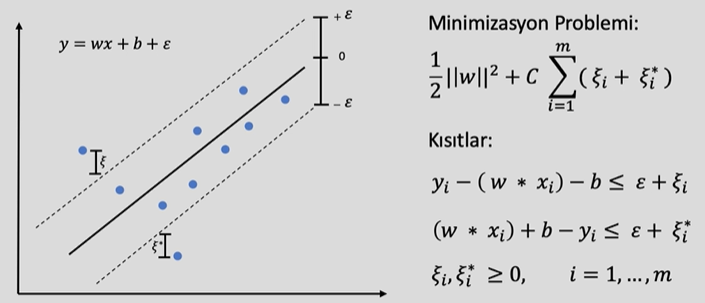

* I: KSI: Uç/Aykırı değerler. Kabul edilebilir aralığın dışı.
* C: Karmaşıklık/ceza parametresi
* Kıstılar: "Öyle bir denklem bulmana yardımcı olacağım ki, gerçek değerler ile tahmin edilen değerler arasındaki farklar, regresyon eğrisinin iki yönünden belirli bir epsilon ve ksi değerinden daha uzakta olmayacak."

Bu I ile gözüken dışarıda kalan artıklar, doğrusal regresyonumuzu belirleyen yegane şeylerdir. bu sebeple onlara ceza uygulayıp daha da yakınlaştırmaya çalışmak mühim olandır. Yani bu aykırı değerler, eğriyi belirler.

## Linear SVR

In [39]:
hit = pd.read_csv("Hitters.csv") # bazı basketbolcuların özelliklerini veren veriseti

df = hit.copy()

df = df.dropna()

dms = pd.get_dummies(df[['League', 'Division', 'NewLeague']])

y = df["Salary"] # bağımlı değişkenimizi kaydetmiş olduk

X_ = df.drop(["Salary","League","Division","NewLeague"],axis=1).astype("float")

X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [40]:
X_train = pd.DataFrame(X_train["Hits"])
X_test = pd.DataFrame(X_test["Hits"]) # ilk SVR'ımız doğrusal SVR olacağından dolayı sadece hits'in salary'e olan etkisine bakacağız basit bir şey olması açısından

In [41]:
print("X_train: \n",X_train.head(3)) # bu şekilde, Hitters.csv içerisindeki sadece hits sütununu barındıracak yani 
print("\nX_test: \n",X_test.head(3))
print("\ny_train: \n",y_train.head(3))
print("\ny_test: \n",y_test.head(3))

X_train: 
       Hits
183   91.0
229  144.0
286  152.0

X_test: 
       Hits
148  136.0
154  147.0
318  136.0

y_train: 
 183     125.0
229    1940.0
286     940.0
Name: Salary, dtype: float64

y_test: 
 148    850.0
154    277.5
318    875.0
Name: Salary, dtype: float64


In [42]:
from sklearn.svm import SVR

In [43]:
svr_model = SVR(kernel="linear").fit(X_train, y_train)

In [44]:
y_pred = svr_model.predict(X_train)

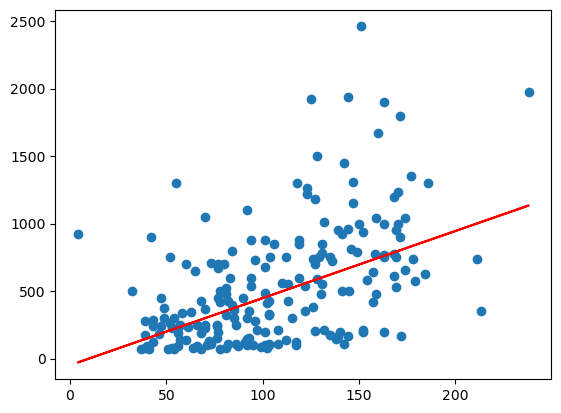

In [45]:
plt.scatter(X_train, y_train)
plt.plot(X_train, y_pred, color="r"); # burada aslında kurmuş olduğumuz modeli, X_train ve y_train versetlerindeki doğrusunu göstermiş olduk. yani burada, X_train, y_train ve bunlarla eğitilmiş modelin bunlar içerisindeki doğrusunu görmüş oluyoruz

In [46]:
from sklearn.linear_model import LinearRegression
lm_model = LinearRegression().fit(X_train, y_train)
lm_pred = lm_model.predict(X_train)
print("y = {0} + {1} x".format(lm_model.intercept_, lm_model.coef_[0]))

# kurmuş olduğumzu hits'in salary üzerindeki etkisine göre eğitilmiş 
# modelin denklemi bu şekilde y=-8.81 + 5.17x    -> yani b0 = -8.81..   b1 = 5.17..
# ama bu svr değil, linear regression denklemi

y = -8.814095480334572 + 5.1724561354706875 x


Text(0.5, 1.0, 'SVR vs Linear Regression')

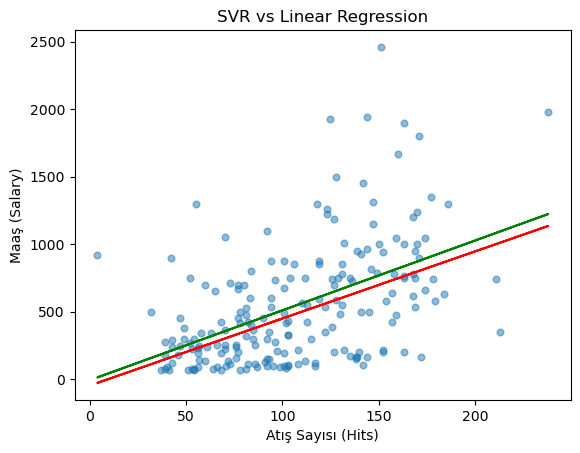

In [47]:
plt.scatter(X_train, y_train, alpha=0.5, s=23)
plt.plot(X_train, lm_pred, 'g')
plt.plot(X_train, y_pred, color='r')

plt.xlabel("Atış Sayısı (Hits)")
plt.ylabel("Maaş (Salary)")
plt.title("SVR vs Linear Regression")

# linear regression ile svr'ın doğrularını aynı veriseti içerisinde karşılaştıran denklem. kırmızı olan svr, yeşil olan linear regression
# bunu nereden biliyorum? az önce aynı değer için tahminleri aldığımda linear regression her zaman svr'dan daha yüksek sonuçlar verdiği için, svr'dan daha üstte olacak denklemi her zaman 
# peki neden svr aşağıda, linear regression yukarıda? Çünkü SVR tanımında da yazdığımız üzere, svr kendini verinin daha çok olduğu yerlere konumlandırıp aykırıları dışlayacak.
# linear regression ise aykırılardan etkilendiği için, yukarıdaki aykırılar onu daha çok yukarı çekti. ancak svr verinin çoğunluğunun temsil ettiği yer olan aşağıda kaldı. bu da bunun kanıtı 

## Tahmin

In [49]:
print("SVR Modelimizin Tahmin Denklemi:\n\ny =",f"{svr_model.intercept_[0]} + {svr_model.coef_[0][0]}")

SVR Modelimizin Tahmin Denklemi:

y = -48.69756097561513 + 4.969512195122093


In [50]:
svr_model.predict([[91]]) # bu şekilde direkt değeri vererek de öğrenebiliriz. Hiti 91 birim olan birinin alacağı maaş 403 birimmiş

C:\Users\since\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


array([403.52804878])

In [51]:
# train seti üzerinden tahmin gerçekleştirme
y_pred = svr_model.predict(X_train)

In [52]:
# train error bulma
np.sqrt(mean_squared_error(y_pred, y_train))

389.97589200276997

In [53]:
# test veri seti üzerinden tahmin gerçekleştirme
y_pred = svr_model.predict(X_test)

In [54]:
# test error'u bulma
np.sqrt(mean_squared_error(y_pred, y_test))

459.0187960365147

## Model Tuning

In [56]:
svr_params = {"C":np.arange(0.1, 2, 0.1)}
svr_cv_model = GridSearchCV(svr_model, svr_params, cv=10).fit(X_train, y_train)

In [57]:
svr_cv_model.best_params_ # bize sana en iyi gidecek olan 0.1 c parametresi abim demiş
svr_cv_model.best_params_

{'C': 0.1}

In [58]:
svr_tuned = SVR(kernel="linear", C = pd.Series(svr_cv_model.best_params_)[0]).fit(X_train, y_train)

C:\Users\since\AppData\Local\Temp\ipykernel_14280\3643996178.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  svr_tuned = SVR(kernel="linear", C = pd.Series(svr_cv_model.best_params_)[0]).fit(X_train, y_train)


In [59]:
y_pred = svr_tuned.predict(X_test)

In [60]:
np.sqrt(mean_squared_error(y_test, y_pred))

458.198966781116

# Nonlinear SVR

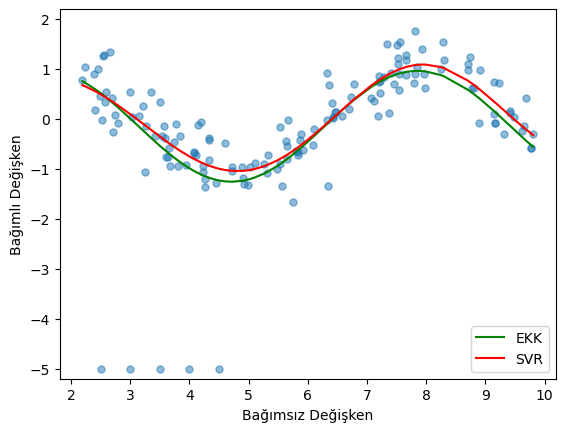

In [62]:
np.random.seed(3)

x_sim = np.random.uniform(2, 10, 145)
y_sim = np.sin(x_sim) + np.random.normal(0, 0.4, 145)

x_outliers = np.arange(2.5, 5, 0.5)
y_outliers = -5 * np.ones(5)

x_sim_idx = np.argsort(np.concatenate([x_sim, x_outliers]))
x_sim = np.concatenate([x_sim, x_outliers])[x_sim_idx]
y_sim = np.concatenate([y_sim, y_outliers])[x_sim_idx]

from sklearn.linear_model import LinearRegression
ols = LinearRegression()
ols.fit(np.sin(x_sim)[:, np.newaxis], y_sim)
ols_pred = ols.predict(np.sin(x_sim)[:, np.newaxis])

from sklearn.svm import SVR
eps = 0.1
svr = SVR(kernel='rbf', epsilon=eps)
svr.fit(x_sim[:, np.newaxis], y_sim)
svr_pred = svr.predict(x_sim[:, np.newaxis])

plt.scatter(x_sim, y_sim, alpha=0.5, s=26)
plt_ols, = plt.plot(x_sim, ols_pred, 'g')
plt_svr, = plt.plot(x_sim, svr_pred, color='r')

plt.xlabel("Bağımsız Değişken")
plt.ylabel("Bağımlı Değişken")
plt.ylim(-5.2, 2.2)
plt.legend([plt_ols, plt_svr], ['EKK', 'SVR'], loc=4);

# ekk ile kıyaslaması ve kendisi bu şekilde gözüküyor diye yaptık bunca işlemi

In [63]:
hit = pd.read_csv("Hitters.csv") # bazı basketbolcuların özelliklerini veren veriseti

df = hit.copy()

df = df.dropna()

dms = pd.get_dummies(df[['League', 'Division', 'NewLeague']])

y = df["Salary"] # bağımlı değişkenimizi kaydetmiş olduk

X_ = df.drop(["Salary","League","Division","NewLeague"],axis=1).astype("float")

X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [64]:
svr_rbf = SVR(kernel="rbf").fit(X_train, y_train)

## Tahmin

In [66]:
y_pred = svr_rbf.predict(X_test)

In [67]:
np.sqrt(mean_squared_error(y_test, y_pred))

460.0032657244849

## Model Tuning

In [69]:
# optimize edilmesi gereken "c" ceza parametresinin optimum değerini bulacağız burada

In [70]:
svr_params={"C":[0.1,0.4,5,10,20,30,40,50]}

svr_cv_model = GridSearchCV(svr_rbf, svr_params, cv=10).fit(X_train, y_train)

In [71]:
svr_cv_model.best_params_

{'C': 50}

## Final Model

In [73]:
svr_tuned = SVR(kernel = "rbf", C=pd.Series(svr_cv_model.best_params_)[0]).fit(X_train, y_train)

C:\Users\since\AppData\Local\Temp\ipykernel_14280\2363303603.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  svr_tuned = SVR(kernel = "rbf", C=pd.Series(svr_cv_model.best_params_)[0]).fit(X_train, y_train)


In [74]:
y_pred = svr_tuned.predict(X_test)

In [75]:
np.sqrt(mean_squared_error(y_pred, y_test))

428.00406888095694

# Artificial Neural Networks (Yapay Sinir Ağları)

insan beyninin bilgi işleme şeklini referans alan sınıflandırma ve regresyon problemleri için kullanılabilen kuvvetli makina öğrenmesi algoritmalarından birisidir.

Gerçek insan sinir hücresi:

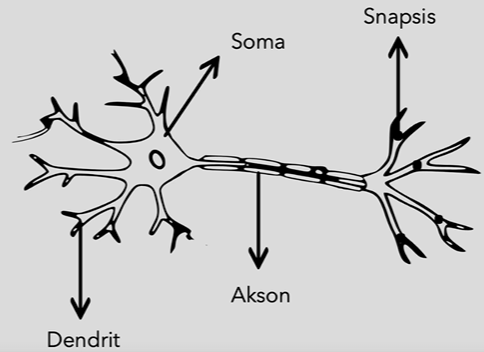

Dendritler alınan sinyalleri hücre çekirdeğine iletir. Hücre çekirdekleri de gelen sinyallerin önemine göre sıralandırıp ona göre aksiyona geçer. Soma, Dendritten gelen sinyalleri hücre çekirdeğine ileten bir alandır. Akson ise çekirdekten gelen bilgileri sinapsislere iletir. Sinapsislerin görevi ise gelen sinyali alıp, ön işleme tabi tutup, diğer hücrelere iletmektir.

Yapay Sinir Hücresi:

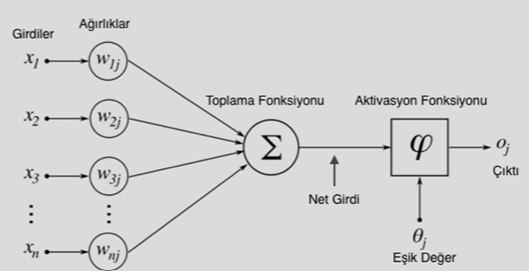

* Girdiler: Dendritler
* Ağırlıklar: Gelen sinayallerinin önemlerinin farklılığı
* Toplama fonksiyonu: Soma
* Aktivasyon Fonksiyonu: Sinapsis


Girdiler: Regresyon bölümünde gördüğümüz bağımsız değişkenlerin değerleridir.

Burada aslında başlangıçta ağırlıklar rastgele olarak değer alır, sonrasında hata çıktısına bakıldıkça, bu iterasyon devam ettikçe ağırlıklar güncellenmiş olur. Yani ağırlıklar hangi değişkenin ne kadar öneme sahip olduğunu belirlemekte kullanıldığı için, çıktılara göre kendisini güncelleyerek yeni çıktılar ve yeni kombinasyonlar elde ederek en optimum değere kendini iterasyonlar sonucu güncellemiş oluyor, aslında bu esnada öğrenme gerçekleşmiş oluyor. Bu gördüğümüz yapılar bir araya geldikçe yapay sinir ağlarını oluşturur.

Yapay Sinir Ağı:

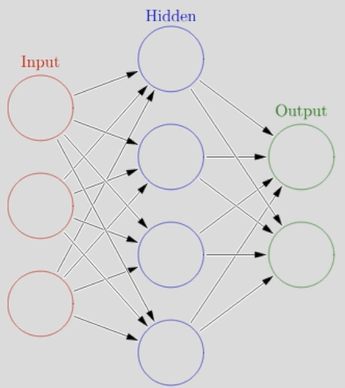


Formüller:

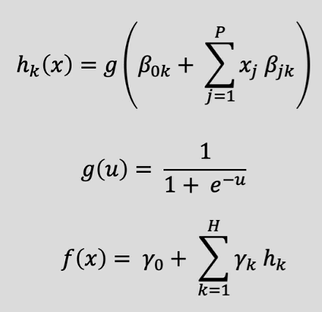


Daha önce de söylediğimiz gibi, katsayılarımız başlangıçta random olarak atanır, zamanla bu katsayıların güncellenerek doğru hallerine gelmesi beklenir. Bu optimum parametre değerleri de Backpropagation ile bulunacak. Bu algoritma, türev kullanarak çalışan bir yöntemdir. Fakat bu tek doğru yöntem değildir, diğer parametre bulucularla daha doğru yapılabilir, yapılırsa onlar tercih edilmelidir.

Yapay sinir ağları overfitting yapmaya meyillidir. Bu durumun önüne geçilmesi için çeşitli yaklaşımlar bulunmuş. Bunlardan birincisi: katsayıları bulan iteratif algoritmaları erken durdurma yöntemidir. 

Ridge regresyonun cezalandırma yöntemine benzer cezalandırma yöntemimiz:

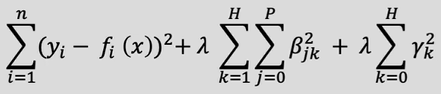

In [78]:
hit = pd.read_csv("Hitters.csv") # bazı basketbolcuların özelliklerini veren veriseti

df = hit.copy()

df = df.dropna()

dms = pd.get_dummies(df[['League', 'Division', 'NewLeague']])

y = df["Salary"] # bağımlı değişkenimizi kaydetmiş olduk

X_ = df.drop(["Salary","League","Division","NewLeague"],axis=1).astype("float")

X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [79]:
from sklearn.preprocessing import StandardScaler # ölçeklendirme işlemini yapmak için
from sklearn.neural_network import MLPRegressor # Artificial neural network modelimizi kurmak için. mlp: multi layer perceptron

In [80]:
# burada eğer değişkenlerin varyans yapıları birbirlerinden çok farklıysa, elde edilen sonuçların güvenilirliği çok fazla düşecektir. Bu nedenle
# Artificial neural network'de, değişken standartlaştırma işleminin yapılması önem arz etmektedir.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [81]:
mlp_model = MLPRegressor().fit(X_train_scaled, y_train)

C:\Users\since\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [82]:
mlp_model.n_layers_ # artificial neural networkümüz 3 katmanlı. input katmanı, hidden katman, output katmanı

3

In [83]:
mlp_model.hidden_layer_sizes # gizli katman içerisindeki neuron sayısı 100 adetmiş. ama hidden katmanı sayısı 1 tabi

(100,)

## Tahmin

In [85]:
y_pred = mlp_model.predict(X_train_scaled)

In [86]:
np.sqrt(mean_squared_error(y_pred, y_train))

670.4334281278277

In [87]:
y_pred = mlp_model.predict(X_test_scaled)

In [88]:
np.sqrt(mean_squared_error(y_pred, y_test))

661.7377281959858

## Model Tuning

In [90]:
mlp_params = {'alpha':[0.1, 0.01, 0.02, 0.005], 
              'hidden_layer_sizes':[(20,20), (100,50,150), (300,200,150)],
              'activation':['relu','logistic']} 

# burada denemesi için olan parametreleri ayarladık. birazdan denetip en optimumları öğrenicez

In [91]:
mlp_cv_model = GridSearchCV(mlp_model, mlp_params, cv=10)

In [92]:
mlp_cv_model.fit(X_train_scaled, y_train)

C:\Users\since\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\since\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\since\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\since\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\since\anaconda3\Lib\site-packages\sklearn\neural_network\_multi

GridSearchCV(cv=10, estimator=MLPRegressor(),
             param_grid={'activation': ['relu', 'logistic'],
                         'alpha': [0.1, 0.01, 0.02, 0.005],
                         'hidden_layer_sizes': [(20, 20), (100, 50, 150),
                                                (300, 200, 150)]})

In [93]:
mlp_cv_model.best_params_

{'activation': 'relu', 'alpha': 0.1, 'hidden_layer_sizes': (100, 50, 150)}

In [94]:
mlp_tuned = MLPRegressor(alpha=0.02, hidden_layer_sizes=(100, 50, 150), activation='relu').fit(X_train_scaled, y_train)

C:\Users\since\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [95]:
y_pred = mlp_tuned.predict(X_test_scaled)

In [96]:
np.sqrt(mean_squared_error(y_pred, y_test)) 

# parametreleri ayarladıktan sonra hata yarısına düştü resmen çüş eşşeğin götü
# bu zamana kadar denediğimiz tüm modeller arasında en düşük hatayı veren bu arkadaş oldu

352.62143939140486

# Classification and Regression Trees (CART)

Amaç: Veriseti içerisindeki karmaşık yapıları basit karar yapılarına dönüştürmektir. 

Heterojen verisetleri, belirlenmiş bir hedef değişkene göre homojen alt gruplara ayrılır.

Aslında bundan sonra göreceğimiz algoritmalara göre zayıf bir algoritmadır ancak bunu anlamak, diğerlerini anlamaktan geçmekte olduğundan CART, öneme sahiptir.

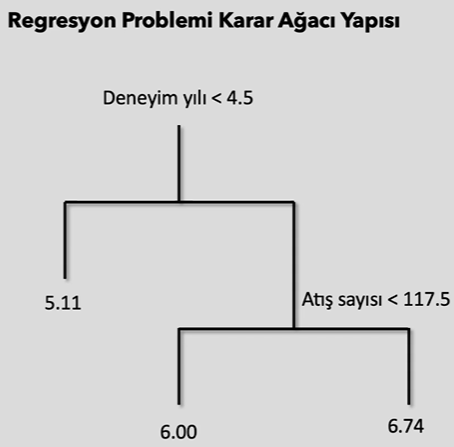

Görseli yorumlayacak olursak: Tecrübesi 4.5'den küçükse, maaşı 5.11'dir. Tecrübesi 4.5'e eşit ya da büyükse, o zaman atış sayısına bakarız. Tecrübesi 4.5'e eşit ya da büyükse ve Atış sayısı 117.5'den küçükse, maaşı 6'dır. Tecrübesi 4.5'e eşit ya da büyükse ve Atış sayısı 117.5'den büyük ya da eşitse, maaşı 6.74'dür.

* 1 root (Deneyim yılı)
* 2 node (Dallanma noktaları)
* 3 leaf (5.11, 6, 6.74)
* Root, bağımlı değişkenimizi açıklamakta en önemli değişkendir

Burada görülebileceği üzere, karmaşık verisetini, homojen alt dallara ayırarak daha düzenli bir yapı sağlar Decision Trees. Örneğin deneyimi 5 yıldan fazla olanlar sola, az olanları sağa aldığında, daha basit ve anlaşılır bir yapı ile karşı karşıya kalmış oluyoruz. Bu bölünme işlemlerini, Gini katsayısı, Ki-kare değeri, entropi gibi çeşitli decision kuralları ile yapıyor.


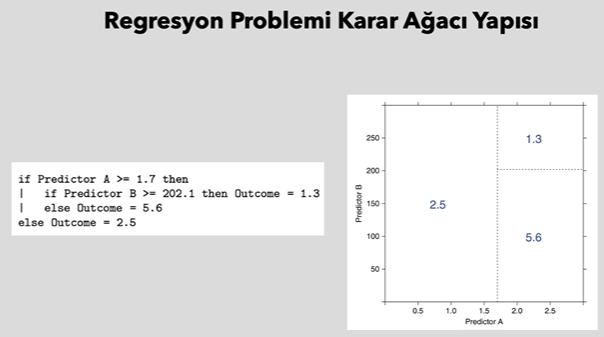


Bu dallanmaların fazlalığı overfitting'e sebep oluyor. Bu sebeple dallanmalar kontrolde tutulmalı ki koymuş olduğumuz conditionlar işe yarasın. Burada bu karmaşıklığı durduracak bir karmaşıklık parametresi var, bunun diğer adı da önceden gördüğümüz gibi ceza parametresi. Bu değer belirli bir dallanmadan sonra dalların kesilip atılmasını ve bu sayede overfitting'e yol açılmamasını sağlıyor.

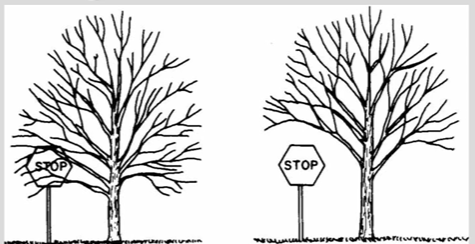


Özetle, eğer verisetimizin genellenmesi(ne olacak) gibi bir kaygımız yok ise, tree yapıları inanılmaz iyidir elimizdeki veriler için. Var olan verileri açıklamakta ve gruplandırmakta üzerlerine yoktur ancak verisetinin genellenmesi ve test ve gerçek hayat verilerinde başarı arandığında sıçabilmektedirler. Internal verilerdeki tahmin yeteneği oldukça iyidir.

## Model

In [100]:
hit = pd.read_csv("Hitters.csv") # bazı basketbolcuların özelliklerini veren veriseti

df = hit.copy()

df = df.dropna()

dms = pd.get_dummies(df[['League', 'Division', 'NewLeague']])

y = df["Salary"] # bağımlı değişkenimizi kaydetmiş olduk

X_ = df.drop(["Salary","League","Division","NewLeague"],axis=1).astype("float")

X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [101]:
X_train = pd.DataFrame(X_train["Hits"])
X_test = pd.DataFrame(X_test["Hits"])

In [102]:
cart_model = DecisionTreeRegressor().fit(X_train, y_train)

C:\Users\since\AppData\Local\Temp\ipykernel_14280\2856666639.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(np.array(X_train)), max(np.array(X_train)), 0.01)
C:\Users\since\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


Text(0, 0.5, 'Maaş (Salary)')

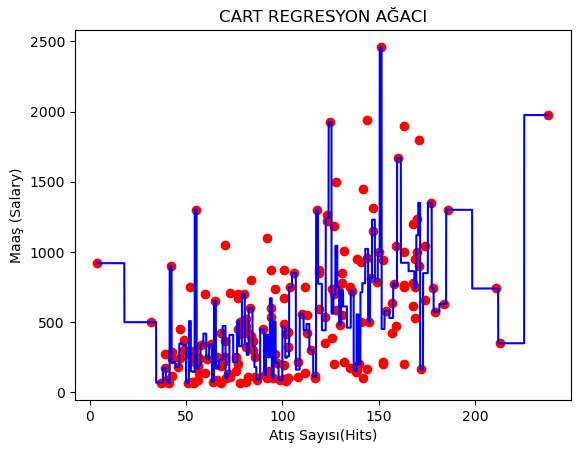

In [103]:
cart_model = DecisionTreeRegressor().fit(X_train, y_train) # normal bir decision tree ile

X_grid = np.arange(min(np.array(X_train)), max(np.array(X_train)), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_grid, cart_model.predict(X_grid), color = 'blue')
plt.title('CART REGRESYON AĞACI')
plt.xlabel('Atış Sayısı(Hits)')
plt.ylabel('Maaş (Salary)')

# DecisionTree'nin arka tarafında neler döndüğünü, karar ağacı yapısının nasıl dağıldığını, yukarı
# dacart_model = DecisionTreeRegressor().fit(X_train, y_train) işlemi ile ne yaptığımızı görelim diye grafik çizdirttik

C:\Users\since\AppData\Local\Temp\ipykernel_14280\2532808214.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(np.array(X_train)), max(np.array(X_train)), 0.01)
C:\Users\since\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


Text(0, 0.5, 'Maaş (Salary)')

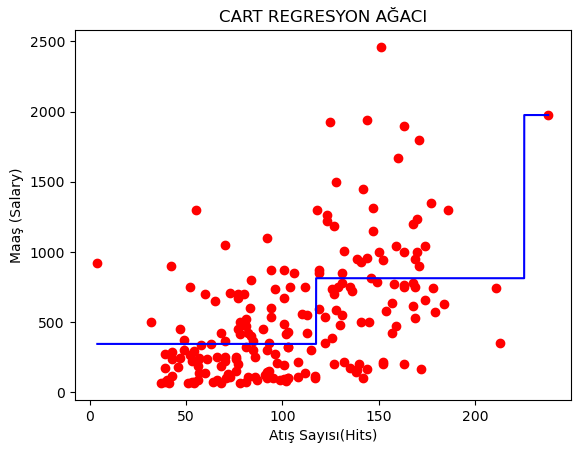

In [104]:
cart_model = DecisionTreeRegressor(max_leaf_nodes = 3).fit(X_train, y_train) # 3 leaf ile decision tree

X_grid = np.arange(min(np.array(X_train)), max(np.array(X_train)), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_grid, cart_model.predict(X_grid), color = 'blue')
plt.title('CART REGRESYON AĞACI')
plt.xlabel('Atış Sayısı(Hits)')
plt.ylabel('Maaş (Salary)')

# Parametrelerin değişiminin decision tree de ne denli büyük değişime yol açtığını göstermek adına
# maximum leaf sayısını 3'e aldığımızda böyle oldu

C:\Users\since\AppData\Local\Temp\ipykernel_14280\1048189539.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(np.array(X_train)), max(np.array(X_train)), 0.01)
C:\Users\since\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


Text(0, 0.5, 'Maaş (Salary)')

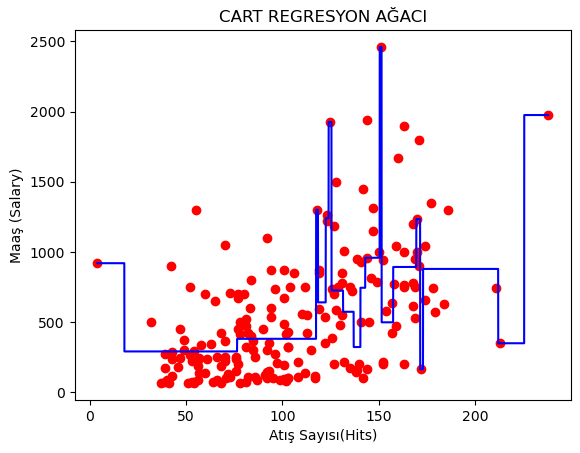

In [105]:
cart_model = DecisionTreeRegressor(max_leaf_nodes = 20).fit(X_train, y_train) # 20 leaf ile decision tree

X_grid = np.arange(min(np.array(X_train)), max(np.array(X_train)), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_grid, cart_model.predict(X_grid), color = 'blue')
plt.title('CART REGRESYON AĞACI')
plt.xlabel('Atış Sayısı(Hits)')
plt.ylabel('Maaş (Salary)')

# bu 3 grafikten anladığımız, bu ve diğer parametrelerin önemi. Parametreler modeli çok etkiler, en optimum olanını bulmak durumundayız her zaman

In [106]:
import sys
!{sys.executable} -m pip install skompiler
!{sys.executable} -m pip install astor

In [107]:
# oluşturmuş olduğumuz modelin kural setlerini almamız gerektiği için bu işlemleri yapmak durumundayız
from skompiler import skompile

print(skompile(cart_model.predict).to('python/code')) # karar ağacının karar modeli / kuralları

((920.0 if x[0] <= 18.0 else 291.70126415094336 if x[0] <= 76.5 else 
    381.66398387096774) if x[0] <= 117.5 else ((((1300.0 if x[0] <= 118.5 else
    641.0) if x[0] <= 122.5 else 1240.0 if x[0] <= 124.0 else 1925.571) if 
    x[0] <= 125.5 else 725.4860833333333 if x[0] <= 131.5 else (574.0666 if
    x[0] <= 137.0 else 323.0) if x[0] <= 140.5 else 745.0) if x[0] <= 143.0
     else (958.6111111111111 if x[0] <= 150.5 else 2460.0) if x[0] <= 151.5
     else 499.1666666666667 if x[0] <= 157.5 else ((893.1666666666666 if x[
    0] <= 169.5 else 1234.375) if x[0] <= 171.5 else 165.0 if x[0] <= 173.0
     else 879.2083749999999) if x[0] <= 212.0 else 350.0) if x[0] <= 225.5 else
    1975.0)



## Tahmin

In [109]:
x=[91]

In [110]:
# 2 önbceki hücrenin çıktısını direkt yapıştırdım buraya, ve x ile ilgili bir ifade aradığı için bir önceki hücreye de x'i tanımladım.
# önceden manuel olarak tahmin yapardık model.predict([[91]]) gibi. burada da aynısını yaptık. manuel olarak tek bir hits değeri için
# tahmin yaptırttık

((920.0 if x[0] <= 18.0 else 291.70126415094336 if x[0] <= 76.5 else 
    381.66398387096774) if x[0] <= 117.5 else ((((1300.0 if x[0] <= 118.5 else
    641.0) if x[0] <= 122.5 else 1240.0 if x[0] <= 124.0 else 1925.571) if 
    x[0] <= 125.5 else 725.4860833333333 if x[0] <= 131.5 else (574.0666 if
    x[0] <= 137.0 else 323.0) if x[0] <= 140.5 else 745.0) if x[0] <= 143.0
     else (958.6111111111111 if x[0] <= 150.5 else 2460.0) if x[0] <= 151.5
     else 499.1666666666667 if x[0] <= 157.5 else ((893.1666666666666 if x[
    0] <= 169.5 else 1234.375) if x[0] <= 171.5 else 165.0 if x[0] <= 173.0
     else 879.2083749999999) if x[0] <= 212.0 else 350.0) if x[0] <= 225.5 else
    1975.0)

381.66398387096774

In [111]:
cart_model.predict([[90]]) # görüldüğü üzere bir öncekiyle aynı çıktı

C:\Users\since\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([381.66398387])

In [112]:
y_pred = cart_model.predict(X_test)

In [113]:
np.sqrt(mean_squared_error(y_pred, y_test))

446.72035850924783

## Model Tuning

In [115]:
cart_model = DecisionTreeRegressor().fit(X_train, y_train)
y_pred = cart_model.predict(X_test)
np.sqrt(mean_squared_error(y_pred, y_test))

468.49579052913884

In [134]:
params = {'min_samples_split':range(2,100), 'max_leaf_nodes':range(1,99)}

In [136]:
cart_cv_model = GridSearchCV(cart_model, params, cv=10).fit(X_train, y_train)

C:\Users\since\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
980 fits failed out of a total of 96040.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
980 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\since\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\since\anaconda3\Lib\site-packages\sklearn\tree\_classes.py", line 1247, in fit
    super().fit(
  File "C:\Users\since\anaconda3\Lib\site-packages\sklearn\tree\_classes.py", line 177, in fit
    self._validate_params()
  File "C:\Users\since\anaconda3\Lib\site-packages\sklearn\base.py", 

In [137]:
cart_cv_models.best_params_

NameError: name 'cart_cv_models' is not defined

In [142]:
cart_tuned = DecisionTreeRegressor(max_leaf_nodes=9, min_samples_split=76).fit(X_train, y_train)

In [144]:
y_pred = cart_tuned.predict(X_test)

In [146]:
np.sqrt(mean_squared_error(y_pred, y_test))

423.406689243066

# Bagged Trees

Temeli, bootstrap yöntemiyle oluşturulan **birden fazla karar ağacının ürettiği tahminlerin bir araya getirilerek** değerlendirilmesine dayanır.

Yani özetle, birden fazla karar ağacı bir araya getirilip değerlendirme sağlanıyor. Her bir modele bir tahmin soruluyor ve her modelin söylediği tahmin, bir arada değerlendiriliyor.

Birden fazla aynı algoritmanın bir araya gelerek oluşturduğu yapıları işeyeceğimiz kısma geldik. Bagging, Random Forest, XGBoost, GBM. Bunlar kendi içlerinde birden fazla ağaç içerek algoritmalar. Bunun bir de birbirinden farklı birden fazla algoritmanın bir araya gelerek oluşturduğu yapılar versiyonu da var.

Bagging Çalışma Prensibi:

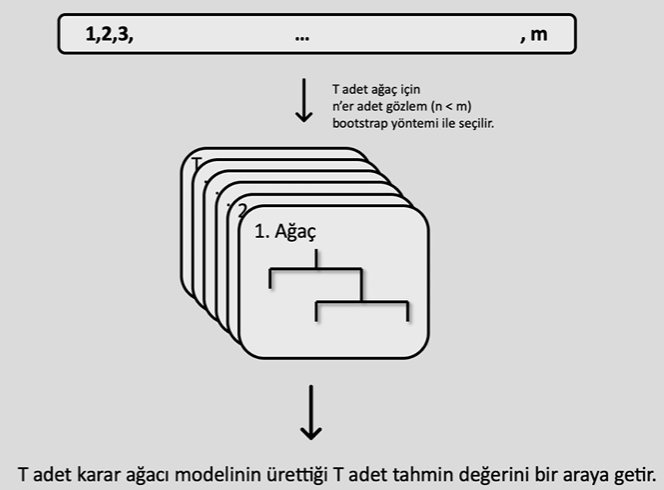

* Buradaki ağaçların daha önceki ağaçlarla bir bağlılıkları yoktur
* Her bir ağacın kullanılma şansı eşittir
* Çekilen örneklerin 3'de 2'sinin ağaçlar tarafından oluşturulur, 3'de 1'inin ise ağaçların performansının analiz edileceği kısımdır
* Varyansı düşüren, overfitting'e karşı dayanıklı, hata kareler karekökünü düşüren bir yöntemdir
* CART'da ki ağaçların yapraklarını budadıktan sonra ortaya çıkan rassallık problemini gidermiştir Bagging

Random forest'da ise bu ağaçların hepsinin önemi buradaki gibi aynı olmayacak, her bir ağaca ağırlıklar verilip onların dediklerinin önemi daha fazla olacak

In [273]:
hit = pd.read_csv("Hitters.csv") # bazı basketbolcuların özelliklerini veren veriseti

df = hit.copy()

df = df.dropna()

dms = pd.get_dummies(df[['League', 'Division', 'NewLeague']])

y = df["Salary"] # bağımlı değişkenimizi kaydetmiş olduk

X_ = df.drop(["Salary","League","Division","NewLeague"],axis=1).astype("float")

X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [275]:
bag_model = BaggingRegressor(bootstrap_features=True).fit(X_train, y_train)

In [277]:
bag_model.n_estimators # içeriside 10 adet ağaç barındırıyormuş

10

In [279]:
bag_model.estimators_ # her biri birbirinden farklı olan 10 adet ağacın içeriğini görmüş olduk

[DecisionTreeRegressor(random_state=626201566),
 DecisionTreeRegressor(random_state=1360723754),
 DecisionTreeRegressor(random_state=1612709779),
 DecisionTreeRegressor(random_state=1080647803),
 DecisionTreeRegressor(random_state=1695051577),
 DecisionTreeRegressor(random_state=1993253671),
 DecisionTreeRegressor(random_state=586660035),
 DecisionTreeRegressor(random_state=2138457680),
 DecisionTreeRegressor(random_state=731393523),
 DecisionTreeRegressor(random_state=463994177)]

In [281]:
bag_model.estimators_features_ # bu her bir farklı ağacın kullandığı değişkenler ve bunların indexlerine eriştik. her bir ağaçtaki bağımsız değişkenler

[array([ 8,  3,  6,  1, 16,  6,  4, 14, 15,  0,  4,  7,  6,  7,  1, 16, 15,
        18, 10]),
 array([10, 10, 18,  4, 12,  9,  4, 15,  1, 17, 11, 17,  8,  6,  1, 15,  0,
        12, 10]),
 array([ 3,  6, 15, 13,  0,  3,  1,  6,  7, 14,  1,  6,  2, 17,  8, 17, 15,
         6, 17]),
 array([ 1,  5,  2,  9, 10,  7, 11,  2,  3,  0, 12,  2,  3,  7,  9, 14, 11,
        11, 14]),
 array([15,  3,  2,  2,  2,  1,  9,  8,  9, 18,  7, 14,  7, 15,  6,  3, 10,
         1,  6]),
 array([ 7,  7, 16, 15,  9,  6,  1, 17,  9,  3,  9,  7, 12,  3, 11, 12,  2,
        17,  7]),
 array([ 3, 12,  0, 18,  4,  9, 16, 15,  1,  2,  7,  5,  2,  6, 17, 10, 10,
        13, 15]),
 array([16, 10, 17, 11,  1, 10,  7,  9, 13, 13,  6,  1, 13,  3, 18, 17, 14,
        10, 13]),
 array([18,  8,  5, 11,  8,  1,  4, 17,  3, 15,  4, 12,  6, 15, 15,  9,  6,
        14, 10]),
 array([ 1,  8, 16,  3,  5,  0, 14,  4,  4,  9, 18,  0,  2, 14, 13, 16,  9,
        10, 17])]

## Tahmin

In [284]:
y_pred = bag_model.predict(X_test) 

# bu sonuç, farklı farklı ağaçların tahminlerinin hepsinin birlikte değerlendirildikten sonra ortaya çıkan sonuç
# konseyin ortak kararı yani 

In [286]:
np.sqrt(mean_squared_error(y_pred, y_test)) 

337.82685561512733

In [240]:
# şimdi her bir ağacın ayrı ayrı tahminini gözlemlemek istersek diye

In [241]:
y_pred1 = bag_model.estimators_[0].fit(X_train, y_train).predict(X_test)
print("Birinci ağacın test hatası:", np.sqrt(mean_squared_error(y_pred1, y_test)))

y_pred2 = bag_model.estimators_[1].fit(X_train, y_train).predict(X_test)
print("İkinci ağacın test hatası:", np.sqrt(mean_squared_error(y_pred2, y_test)))

y_pred3 = bag_model.estimators_[2].fit(X_train, y_train).predict(X_test)
print("Üçüncü ağacın test hatası:", np.sqrt(mean_squared_error(y_pred3, y_test)))

y_pred4 = bag_model.estimators_[3].fit(X_train, y_train).predict(X_test)
print("Dördüncü ağacın test hatası:", np.sqrt(mean_squared_error(y_pred4, y_test)))

y_pred5 = bag_model.estimators_[4].fit(X_train, y_train).predict(X_test)
print("Beşinci ağacın test hatası:", np.sqrt(mean_squared_error(y_pred5, y_test)))

y_pred6 = bag_model.estimators_[5].fit(X_train, y_train).predict(X_test)
print("Altıncı ağacın test hatası:", np.sqrt(mean_squared_error(y_pred6, y_test)))

y_pred7 = bag_model.estimators_[6].fit(X_train, y_train).predict(X_test)
print("Yedinci ağacın test hatası:", np.sqrt(mean_squared_error(y_pred7, y_test)))

y_pred8 = bag_model.estimators_[7].fit(X_train, y_train).predict(X_test)
print("Sekizinci ağacın test hatası:", np.sqrt(mean_squared_error(y_pred8, y_test)))

y_pred9 = bag_model.estimators_[8].fit(X_train, y_train).predict(X_test)
print("Dokuzuncu ağacın test hatası:", np.sqrt(mean_squared_error(y_pred9, y_test)))

y_pred10 = bag_model.estimators_[9].fit(X_train, y_train).predict(X_test)
print("Onuncu ağacın test hatası:", np.sqrt(mean_squared_error(y_pred10, y_test)))

Birinci ağacın test hatası: 479.81330605324234
İkinci ağacın test hatası: 466.8588559380207
Üçüncü ağacın test hatası: 514.6514447745193
Dördüncü ağacın test hatası: 460.9186215279189
Beşinci ağacın test hatası: 445.45607630304363
Altıncı ağacın test hatası: 434.7101401608509
Yedinci ağacın test hatası: 440.3854356967521
Sekizinci ağacın test hatası: 526.9232415356668
Dokuzuncu ağacın test hatası: 534.8132344833384
Onuncu ağacın test hatası: 445.0574005416026


## Model Tuning

In [253]:
bag_model = BaggingRegressor(bootstrap_features=True).fit(X_train, y_train)

In [255]:
bag_params = {"n_estimators":range(2,20)}

In [256]:
bag_cv_model = GridSearchCV(bag_model, bag_params, cv=10).fit(X_train, y_train)

In [264]:
bag_cv_model.best_params_ # en iyi n_estimator sayısının 14 olduğunu sölüor argadaş

{'n_estimators': 14}

## Final Model

In [288]:
bag_model = BaggingRegressor(n_estimators=14, random_state = 45).fit(X_train, y_train)

In [290]:
y_pred = bag_model.predict(X_test)
np.sqrt(mean_squared_error(y_pred, y_test))

346.457987188104

# Random Forests

Bagged Trees'de olduğu gibi birden çok decision tree'nin bir araya getirilerek değerlendirilmesine dayanır. Bagged Trees'den farklı olarak, bir araya getirilen ağaçların hangisinin daha iyi tahmin yaptığına göre ağaçlara ağırlıklar verilir ve daha iyi sonuçlar elde edilir. En iyi tahmini yapanların daha çok söz hakkı olur gibi.

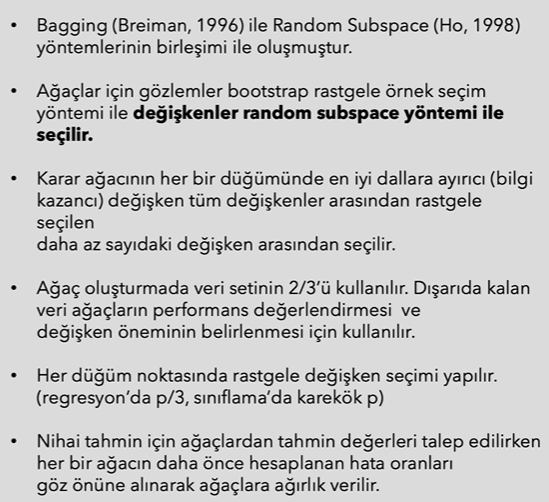

In [294]:
hit = pd.read_csv("Hitters.csv") # bazı basketbolcuların özelliklerini veren veriseti

df = hit.copy()

df = df.dropna()

dms = pd.get_dummies(df[['League', 'Division', 'NewLeague']])

y = df["Salary"] # bağımlı değişkenimizi kaydetmiş olduk

X_ = df.drop(["Salary","League","Division","NewLeague"],axis=1).astype("float")

X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [298]:
from sklearn.ensemble import RandomForestRegressor

In [302]:
rf_model = RandomForestRegressor(random_state=42).fit(X_train, y_train)

## Tahmin

In [307]:
y_pred = rf_model.predict(X_test)

In [309]:
np.sqrt(mean_squared_error(y_pred, y_test))

344.8191624908484

## Model Tuning

Random forest'da 2 adet önemli parametre var:
1) Fit edilecek ağaç sayısı
2) Bölünmelerde kullanılacak olan değişken sayısı
3) Max derinlik (daha az önemli)

In [316]:
rf_params = {'max_depth':list(range(1,10)),
             'max_features': [3,5,10, 15],
             'n_estimators': [200,500,1000,2000]}

In [318]:
rf_model = RandomForestRegressor(random_state=42)

In [324]:
rf_cv_model = GridSearchCV(rf_model, rf_params, cv=10, n_jobs=-1).fit(X_train, y_train)

# n_jobs=-1 yapılınca burada yapılan işlem çok uzun süreceğinden dolayı, böyle sürmemesi adına asenkron ilerle demiş oluyor, 
# işlemci ful performans çalışmış oluyor ve işlemciyi yormuyoruz

In [325]:
rf_cv_model.best_params_

{'max_depth': 8, 'max_features': 3, 'n_estimators': 200}

In [326]:
rf_tuned = RandomForestRegressor(max_depth=8, max_features=3, n_estimators=200).fit(X_train, y_train)

In [327]:
y_pred = rf_tuned.predict(X_test)
np.sqrt(mean_squared_error(y_pred, y_test))

345.7365007471487

In [340]:
importance = pd.DataFrame({"Importance":rf_tuned.feature_importances_*100},
                         index=X_train.columns)

Text(0.5, 0, 'Değişkenlerin Önem Düzeyi')

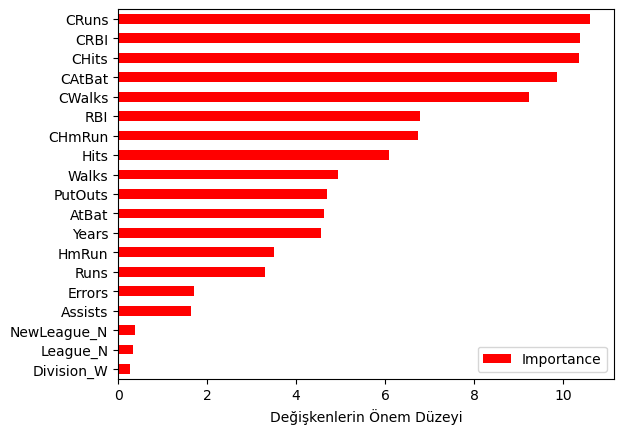

In [346]:
importance.sort_values(by="Importance", axis=0, ascending=True).plot(kind="barh", color="r")
plt.xlabel("Değişkenlerin Önem Düzeyi")

# Burada aslında salar için değişkenlerimizin önem sırasını görmüş olduk

# Gradient Boosting Machines

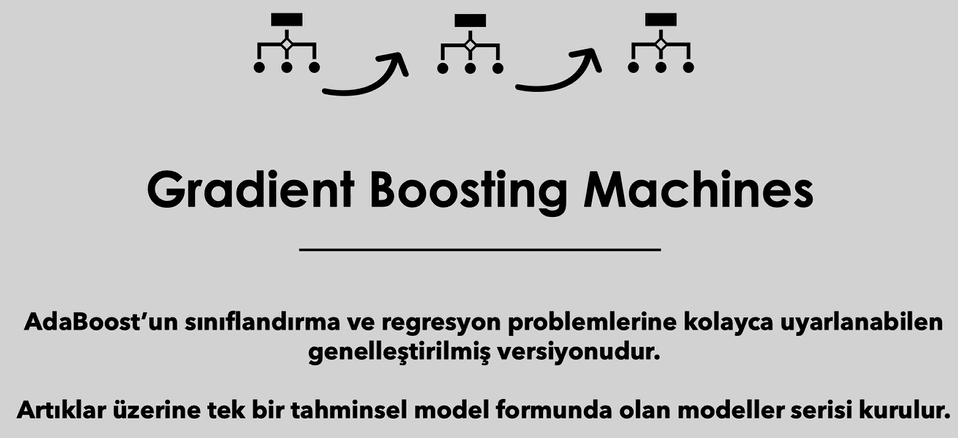

Zayıf sınıflandırıcıların bir araya gelerek güçlü bir sınıflandırıcı oluşturulması fikrini hayata geçiren algoritmadır.

Bagging yöntemlerinde ağaçlar birbirindne bağımsızken boosting yöntemlerinde ağaçlar birbirine bağımlıdır.

AdaBoost:

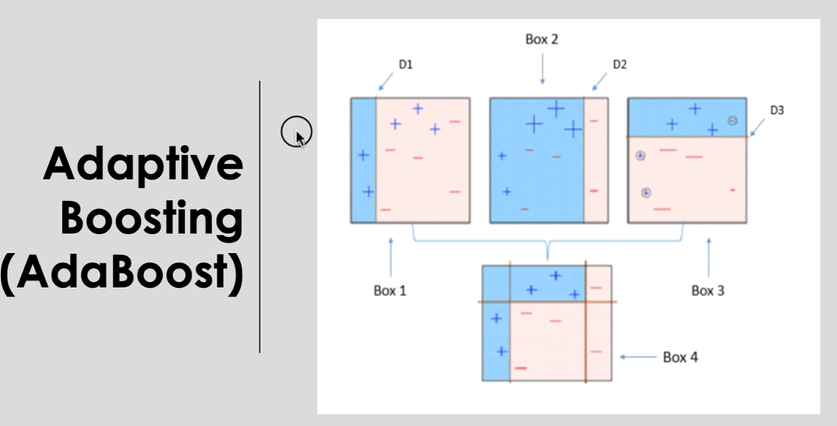

Gördüğümüz üzere adaboost'ta box1, box2 ve box3'de kırmızılar ve maviler sınıflandırma yapılarak ayrılmaya çalışılmış fakat kırmızı alanın içerisine giren maviler ya da mavi alanın içerisine giren kırmızılar mevcut. box1, box2 ve box3 zayıf sınıflandırıcılarının neticesinde güçlü bir sınıflandırıcı olan ve herşeyi doğru sınıflayan Box4 sınıflandırıcısı ortaya çıkmış.

yani özetle, uygun bir cost fonksiyonu üzerinde çalışan bir optimizasyon algoritmasıdır ağaca dayalı bu yöntem.

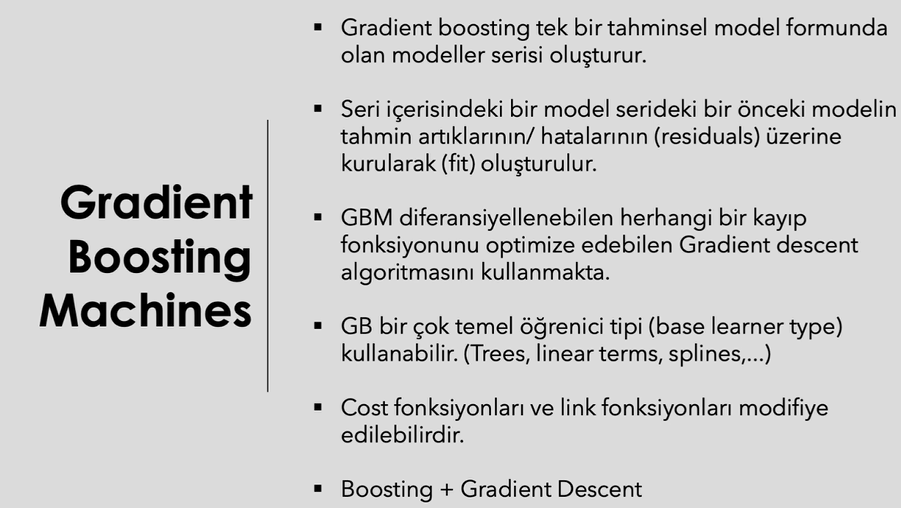

## Gradient Boosting Machines(GBM) Model

In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, ShuffleSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

hit = pd.read_csv("Hitters.csv") # bazı basketbolcuların özelliklerini veren veriseti

df = hit.copy()

df = df.dropna()

dms = pd.get_dummies(df[['League', 'Division', 'NewLeague']])

y = df["Salary"] # bağımlı değişkenimizi kaydetmiş olduk

X_ = df.drop(["Salary","League","Division","NewLeague"],axis=1).astype("float")

X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [63]:
from sklearn.ensemble import GradientBoostingRegressor

In [65]:
gbm_model = GradientBoostingRegressor()

In [67]:
gbm_model.fit(X_train, y_train)

GradientBoostingRegressor()

## Tahmin

In [70]:
y_pred = gbm_model.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

355.5552536714115

## Model Tuning

In [74]:
gbm_params = {
    'learning_rate':[0.001, 0.01, 0.1, 0.2],
    'max_depth':[3,5,8,50,100],
    'n_estimators':[200,500,1000,2000],
    'subsample':[1, 0.5, 0.75]
}

In [76]:
gbm = GradientBoostingRegressor()
gbm_cv_model = GridSearchCV(gbm, gbm_params, cv=10, n_jobs=-1, verbose=2) # yukarıda hazırladığımız farklı parametrelerle denicek hangi parametrelerle en iyi modeller oluşturuluyor 
gbm_cv_model.fit(X_train, y_train)

Fitting 10 folds for each of 240 candidates, totalling 2400 fits


GridSearchCV(cv=10, estimator=GradientBoostingRegressor(), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 8, 50, 100],
                         'n_estimators': [200, 500, 1000, 2000],
                         'subsample': [1, 0.5, 0.75]},
             verbose=2)

In [77]:
gbm_cv_model.best_params_ # hangi parametreler en iyisiymiş bu veriseti için bu gradient boosting modelinde 

{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 2000, 'subsample': 0.5}

In [ ]:
gbm_tuned = GradientBoostingRegressor(learning_rate=0.1, max_depth=5, n_estimators=200, subsample = 0.5) # bir önceki satırın dediğine göre en iyi parametreler bunlarmış, bunları kullan dedi

gbm_tuned.fit(X_train, y_train)

In [ ]:
y_pred = gbm_tuned.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred)) # bu da tune edilmiş(parametreleri ayarlanmış) modelin hatası.

# XGBoost - eXtreme Gradient Boosting

Gradient Boosting Machines(GBM)'in hız ve tahmin performansını artırmak üzere optimize edilmiş, ölçeklenebilir ve farklı platformlara entegre edilebilir halidir.

Kaggle yarışmalarında sıkça kullanılır.

Günümüzde bundan daha çok kullanılan alternatifleri LightGBM ve Catboosttur. 

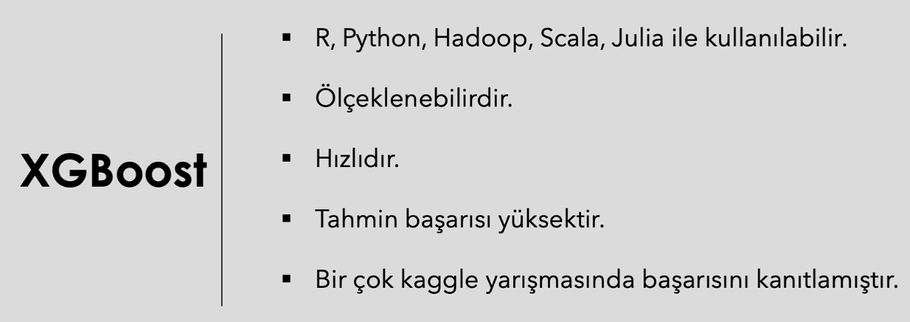

## Model

In [86]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, ShuffleSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

hit = pd.read_csv("Hitters.csv") # bazı basketbolcuların özelliklerini veren veriseti

df = hit.copy()

df = df.dropna()

dms = pd.get_dummies(df[['League', 'Division', 'NewLeague']])

y = df["Salary"] # bağımlı değişkenimizi kaydetmiş olduk

X_ = df.drop(["Salary","League","Division","NewLeague"],axis=1).astype("float")

X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [88]:
!pip install xgboost

   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB 330.3 kB/s eta 0:02:52
   ---------------------------------------- 0.0/56.8 MB 262.6 kB/s eta 0:03:37
   ---------------------------------------- 0.1/56.8 MB 409.6 kB/s eta 0:02:19
   ---------------------------------------- 0.1/56.8 MB 595.3 kB/s eta 0:01:36
   ---------------------------------------- 0.1/56.8 MB 599.1 kB/s eta 0:01:35
   ---------------------------------------- 0.1/56.8 MB 607.9 kB/s eta 0:01:34
   ---------------------------------------- 0.2/56.8 MB 620.6 kB/s eta 0:01:32
   ---------------------------------------- 0.3/56.8 MB 850.6 kB/s eta 0:01:07
   ---------------------------------------- 0.4/56.8 MB 955.7 kB/s eta 0:01:00
   ---------------------------------------- 0.5/56.8 MB 1.0 MB/s eta 0:00:55
   ---------------------------------------- 0.5/56.8 MB 1.1 MB/s eta 0:0

In [96]:
import xgboost as xgb
from xgboost import XGBRegressor

In [98]:
# xgboostun yapımcısının notuna göre numpy veya pandasları kullanmak yerine xgboostun kendi veriyapısını kullanırsak daha performanslı olurmuş

In [104]:
DM_train = xgb.DMatrix(data = X_train, label = y_train) # xgboostun özel veriyapısı bu
DM_test = xgb.DMatrix(data = X_test, label = y_test) # ama aşağıda bunu kullanmadık

## Model

In [102]:
xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

## Tahmin

In [108]:
y_pred = xgb_model.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

366.3863437634965

## Model Tuning

In [113]:
xgb_model # buradaki parametreleri verimize ve modelimize göre optimize etmek için model tuning işlemi gerçekleştireceğiz

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [117]:
xgb_params = {
    'colsample_bytree':[0.4, 0.5, 0.6,0.9,1],
    'n_estimators':[100,200,500,1000],
    'max_depth':[2,3,4,5,6],
    'learning_rate':[0.1, 0.01, 0.5],
}

In [119]:
xgb = XGBRegressor()
xgb_cv_model = GridSearchCV(xgb, param_grid = xgb_params, cv=10, n_jobs=-1, verbose=2)
xgb_cv_model.fit(X_train, y_train)

Fitting 10 folds for each of 300 candidates, totalling 3000 fits


GridSearchCV(cv=10,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=Non...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.4, 0.5, 0.6, 0.9, 1],
                         'learning_rate': [0.1, 0.01, 0.5],
                         'max_depth': [2, 3, 4, 5, 6],
                         'n_estimators': [100, 200, 500, 1000]},
             verbose=2)

In [123]:
xgb_cv_model.best_params_

{'colsample_bytree': 0.4,
 'learning_rate': 0.1,
 'max_depth': 6,
 'n_estimators': 100}

## Final Model

In [127]:
xgb_tuned = XGBRegressor(colsample_bytree= 0.4, learning_rate=0.1, max_depth=6, n_estimators=100)
xgb_tuned.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.4, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [129]:
y_pred = xgb_tuned.predict(X_test)
np.sqrt(mean_squared_error(y_pred, y_test))

343.6101991802883

# Light GBM

Light GBM, XGBoostun eğitim süresi performansını artırmaya yönelik geliştirilen bir diğer GBM türüdür. 2017 yılında Microsoft tarafından açık kaynak olarak geliştirilmiştir. 

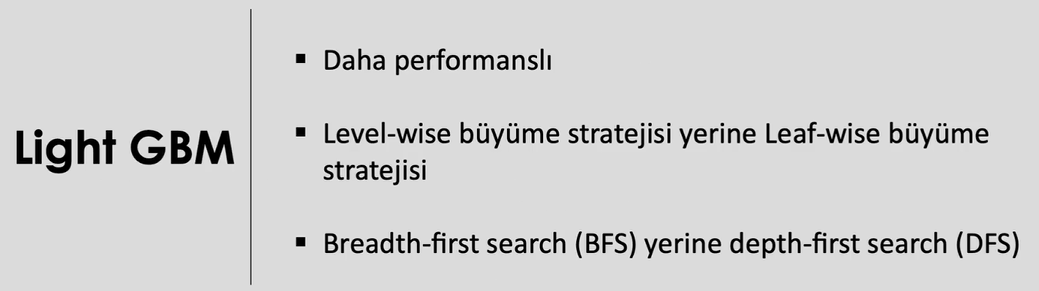

Verisetindeki değerler çok fazla olduğunda XGBoost c++ ile yazılmış olmasına rağmen eğitim süresi çok uzun sürmektedir. Light GBM bu eğitim süresini kısaltmak amaçlı geliştirmeler yapmıştır. 

XGBoost daha geniş kapsamlı bir ilk arama(Breadth first search) yapar, Light GBM ise derinlemesine ilk arama(depth first search) yapar.

In [134]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, ShuffleSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

hit = pd.read_csv("Hitters.csv") # bazı basketbolcuların özelliklerini veren veriseti

df = hit.copy()

df = df.dropna()

dms = pd.get_dummies(df[['League', 'Division', 'NewLeague']])

y = df["Salary"] # bağımlı değişkenimizi kaydetmiş olduk

X_ = df.drop(["Salary","League","Division","NewLeague"],axis=1).astype("float")

X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Model

In [137]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
    --------------------------------------- 0.0/1.5 MB 435.7 kB/s eta 0:00:04
   - -------------------------------------- 0.1/1.5 MB 544.7 kB/s eta 0:00:03
   -- ------------------------------------- 0.1/1.5 MB 653.6 kB/s eta 0:00:03
   ------ --------------------------------- 0.2/1.5 MB 1.1 MB/s eta 0:00:02
   -------- ------------------------------- 0.3/1.5 MB 1.3 MB/s eta 0:00:01
   --------- ------------------------------ 0.3/1.5 MB 1.3 MB/s eta 0:00:01
   --------- ------------------------------ 0.3/1.5 MB 1.3 MB/s eta 0:00:01
   --------- ------------------------------ 0.3/1.5 MB 1.3 MB/s eta 0:00:01
   --------- ------------------------------ 0.3/1.5 MB 1.3 MB/s eta 0:00:01
   ------------ --------------------------- 0.5/1.5 MB 1.1 MB/s eta 0:00:01
   --------------------- ------------------ 0.8/1.5 MB 1.5 MB/s eta 0:00:01
   -----------------

In [139]:
from lightgbm import LGBMRegressor

In [143]:
lgbm = LGBMRegressor()
lgbm_model = lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000163 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 831
[LightGBM] [Info] Number of data points in the train set: 197, number of used features: 19
[LightGBM] [Info] Start training from score 543.483442
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

## Tahmin

In [149]:
y_pred = lgbm_model.predict(X_test, num_iteration=lgbm_model.best_iteration_)
np.sqrt(mean_squared_error(y_pred, y_test))

363.8712087611089

## Model Tuning

In [152]:
lgbm_model

LGBMRegressor()

In [154]:
lgbm_params = {
    'learning_rate':[0.01,0.1,0.5,1],
    'n_estimators':[20,40,100,200,500,1000],
    'max_depth':[1,2,3,4,5,6,7,8],
}

In [158]:
lgbm = LGBMRegressor()
lgbm_cv_model = GridSearchCV(lgbm, lgbm_params, cv=10, n_jobs=-1, verbose=2)
lgbm_cv_model.fit(X_train, y_train)

Fitting 10 folds for each of 192 candidates, totalling 1920 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000664 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 831
[LightGBM] [Info] Number of data points in the train set: 197, number of used features: 19
[LightGBM] [Info] Start training from score 543.483442
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

GridSearchCV(cv=10, estimator=LGBMRegressor(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.5, 1],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8],
                         'n_estimators': [20, 40, 100, 200, 500, 1000]},
             verbose=2)

In [159]:
lgbm_cv_model.best_params_

{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 20}

In [162]:
lgbm_tuned = LGBMRegressor(learning_rate=0.1, max_depth = 6, n_estimators=20).fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 831
[LightGBM] [Info] Number of data points in the train set: 197, number of used features: 19
[LightGBM] [Info] Start training from score 543.483442
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [164]:
y_pred = lgbm_tuned.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

371.5044868943621

# CatBoost (Category Boosting)

Kategorik değişkenlerle otomatik olarak mücadele edebilen, hızlı ve başarılı bir diğer GBM modelidir. Yandex tarafından 2017 yılında geliştirilmiştir.

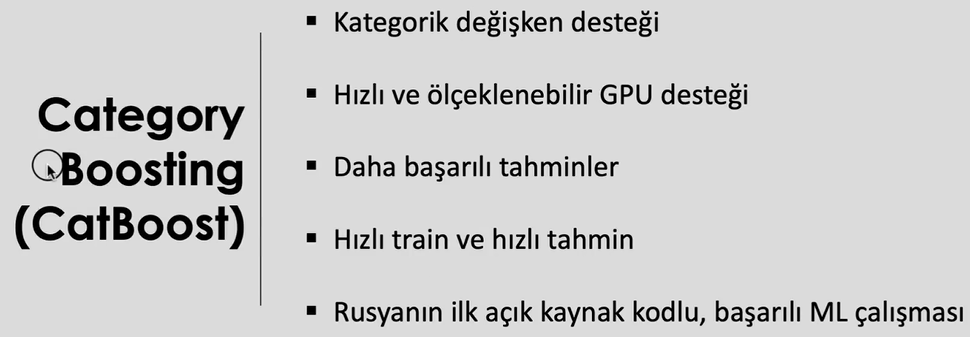

## Model

In [169]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, ShuffleSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

hit = pd.read_csv("Hitters.csv") # bazı basketbolcuların özelliklerini veren veriseti

df = hit.copy()

df = df.dropna()

dms = pd.get_dummies(df[['League', 'Division', 'NewLeague']])

y = df["Salary"] # bağımlı değişkenimizi kaydetmiş olduk

X_ = df.drop(["Salary","League","Division","NewLeague"],axis=1).astype("float")

X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [171]:
!pip install catboost

   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.5 MB 393.8 kB/s eta 0:04:21
   ---------------------------------------- 0.1/102.5 MB 655.4 kB/s eta 0:02:37
   ---------------------------------------- 0.2/102.5 MB 1.1 MB/s eta 0:01:36
   ---------------------------------------- 0.2/102.5 MB 1.1 MB/s eta 0:01:36
   ---------------------------------------- 0.3/102.5 MB 1.2 MB/s eta 0:01:24
   ---------------------------------------- 0.3/102.5 MB 1.2 MB/s eta 0:01:23
   ---------------------------------------- 0.3/102.5 MB 1.2 MB/s eta 0:01:23
   ---------------------------------------- 0.4/102.5 MB 955.7 kB/s eta 0:01:47
   ---------------------------------------- 0.4/102.5 MB 955.7 kB/s eta 0:01:47
   ---------------------------------------- 0.4/102.5 MB 917.0 kB/s eta 0:01:

In [172]:
from catboost import CatBoostRegressor

In [173]:
catb = CatBoostRegressor()
catb_model = catb.fit(X_train, y_train)

Learning rate set to 0.031674
0:	learn: 437.6430699	total: 139ms	remaining: 2m 18s
1:	learn: 431.3923642	total: 143ms	remaining: 1m 11s
2:	learn: 424.8820360	total: 147ms	remaining: 48.8s
3:	learn: 418.2514904	total: 152ms	remaining: 37.9s
4:	learn: 412.6394021	total: 156ms	remaining: 31.1s
5:	learn: 406.6247020	total: 161ms	remaining: 26.7s
6:	learn: 400.5321206	total: 169ms	remaining: 23.9s
7:	learn: 394.6683437	total: 172ms	remaining: 21.4s
8:	learn: 388.2496484	total: 177ms	remaining: 19.5s
9:	learn: 382.9448842	total: 184ms	remaining: 18.2s
10:	learn: 377.2600080	total: 188ms	remaining: 16.9s
11:	learn: 372.4829606	total: 192ms	remaining: 15.8s
12:	learn: 366.6823437	total: 198ms	remaining: 15s
13:	learn: 362.6076230	total: 202ms	remaining: 14.3s
14:	learn: 358.0107745	total: 209ms	remaining: 13.7s
15:	learn: 353.2802665	total: 214ms	remaining: 13.2s
16:	learn: 348.5646265	total: 218ms	remaining: 12.6s
17:	learn: 343.6407912	total: 222ms	remaining: 12.1s
18:	learn: 339.2363847	tot

## Tahmin

In [178]:
y_pred = catb_model.predict(X_test)
np.sqrt(mean_squared_error(y_pred, y_test))

351.194631344607

## Model Tuning

In [192]:
catb_params = {
    'iterations':[200, 500, 1000, 2000],
    'learning_rate':[0.01, 0.03, 0.05, 0.1],
    'depth':[3,4,5,6,7,8],
}

In [196]:
catb = CatBoostRegressor()
catb_cv_model = GridSearchCV(catb, catb_params, cv=5, n_jobs=-1, verbose=2)
catb_cv_model.fit(X_train, y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


KeyboardInterrupt: 

In [198]:
catb_cv_model.best_params_

AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

In [ ]:
catb_tuned = CatBoostRegressor(iterations=200, learning_rate = 0.01, depth=8)

catb_tuned.fit(X_train, y_train)

In [200]:
y_pred = catb_tuned.predict(X_test)
np.sqrt(mean_squared_error(y_pred, y_test))

NameError: name 'catb_tuned' is not defined